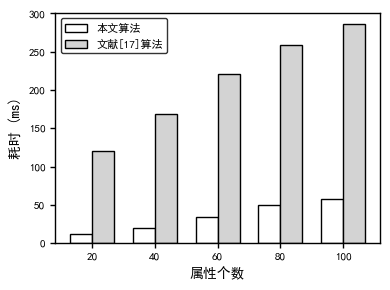

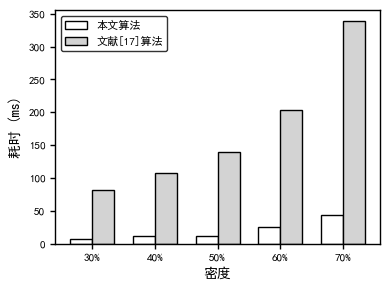

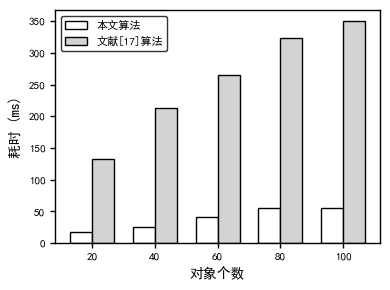

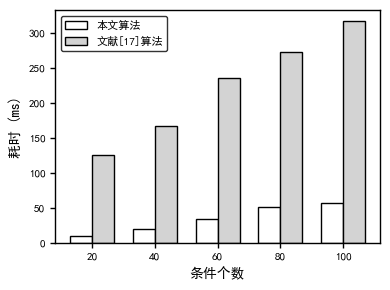

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import re

# 设置支持中文的字体，避免标签显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei', 'Songti SC', 'Arial Unicode MS'] # 适配 Windows/Mac
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号

# ================= 新增：全局调大字号设置 =================
plt.rcParams['axes.labelsize'] = 10  # 坐标轴标签字号 耗时 (ms), 属性个数
plt.rcParams['xtick.labelsize'] = 8 # X轴坐标值/刻度字号 "30%", "40%"
plt.rcParams['ytick.labelsize'] = 8 # Y轴坐标值/刻度字号
plt.rcParams['legend.fontsize'] = 8 # 图例字号 本文算法
# ==========================================================

# ================= 新增：全局调大图框和刻度线宽 =================
plt.rcParams['axes.linewidth'] = 1.0      # 整个图表的边框（包括横纵坐标轴）线宽，默认约为0.8
plt.rcParams['xtick.major.width'] = 1.0   # X轴主刻度线的线宽
plt.rcParams['ytick.major.width'] = 1.0   # Y轴主刻度线的线宽

# ================= 新增：全局图例边框设置 =================
plt.rcParams['legend.edgecolor'] = 'black'  # 图例边框颜色
plt.rcParams['patch.linewidth'] = 1.0        # 这会影响图例边框的默认宽度

def read_and_average(filepath):
    """
    读取文件并计算两列的平均值
    """
    col1, col2 = [], []
    if os.path.exists(filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                # 过滤空行
                if line:
                    parts = line.split(',')
                    if len(parts) == 2:
                        col1.append(float(parts[0]))
                        col2.append(float(parts[1]))
    # 如果文件有数据，则返回平均值；否则返回(0,0)
    if col1 and col2:
        return np.mean(col1), np.mean(col2)
    return 0, 0

# 路径配置
base_dir = '../data/input'
output_dir = '../data/output'

# 1. 使用正则表达式从文件名中动态获取 X 轴坐标
# 【修改点】增加了 condi_x
attr_x, obj_x, dense_x, condi_x = [], [], [], []

if os.path.exists(base_dir):
    for filename in os.listdir(base_dir):
        # 匹配 attr_数字.txt
        match_attr = re.match(r'attr_(\d+)\.txt', filename)
        if match_attr:
            attr_x.append(int(match_attr.group(1)))
            
        # 匹配 obj_数字.txt
        match_obj = re.match(r'obj_(\d+)\.txt', filename)
        if match_obj:
            obj_x.append(int(match_obj.group(1)))
            
        # 匹配 dense_浮点数.txt
        match_dense = re.match(r'dense_([\d.]+)\.txt', filename)
        if match_dense:
            dense_x.append(float(match_dense.group(1)))

        # 【新增】匹配 condi_数字.txt
        match_condi = re.match(r'condi_(\d+)\.txt', filename)
        if match_condi:
            condi_x.append(int(match_condi.group(1)))

# 对提取的数值进行排序，确保横坐标按从小到大的顺序排列
attr_x.sort()
obj_x.sort()
dense_x.sort()
condi_x.sort()  # 【新增】

# 确保输出文件夹存在，如果不存在则自动创建
os.makedirs(output_dir, exist_ok=True)

# 获取各类别的均值
attr_means = [read_and_average(f'{base_dir}/attr_{x}.txt') for x in attr_x]
obj_means = [read_and_average(f'{base_dir}/obj_{x}.txt') for x in obj_x]
dense_means = [read_and_average(f'{base_dir}/dense_{x}.txt') for x in dense_x]
condi_means = [read_and_average(f'{base_dir}/condi_{x}.txt') for x in condi_x]  # 【新增】

# 解包均值数据
attr_inc, attr_full = zip(*attr_means) if attr_means else ((), ())
obj_inc, obj_full = zip(*obj_means) if obj_means else ((), ())
dense_inc, dense_full = zip(*dense_means) if dense_means else ((), ())
condi_inc, condi_full = zip(*condi_means) if condi_means else ((), ())  # 【新增】

width = 0.35 # 柱子的宽度

# 【修改点】去掉了参数 title
def plot_and_save_double_bars(x_labels, inc_data, full_data, xlabel, output_filename):
    """
    绘制单独的双柱状图并保存到指定路径
    """
    # 每次调用都创建一张新的独立画布
    fig, ax = plt.subplots(figsize=(4, 3))
    x = np.arange(len(x_labels))
    
    # 增量算法柱：深灰色背景 + 正向斜杠 (这里代码颜色为white，如果需要深灰可改回 darkgray)
    ax.bar(x - width/2, inc_data, width, label='本文算法', 
           color='white', edgecolor='black', linewidth=1.0)
    
    # 全量算法柱：白色背景 + 反向斜杠 (这里颜色为 lightgray)
    ax.bar(x + width/2, full_data, width, label='文献[17]算法', 
           color='lightgray', edgecolor='black', linewidth=1.0)
    
    # 设置图表文字与刻度
    ax.set_ylabel('耗时 (ms)')
    ax.set_xlabel(xlabel)
    # 【修改点】移除了 ax.set_title(title)
    
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.legend()

    # 自动调整子图间距
    plt.tight_layout()
    
    # 拼接完整的保存路径并保存图片 (使用 dpi=300 保证清晰度)
    save_path = os.path.join(output_dir, output_filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    # 在Jupyter中展示当前图表 (如果在命令行运行，可注释掉此行)
    plt.show()
    
    # 关闭画布，防止下一次绘图时发生重叠或内存泄漏
    plt.close(fig)

# 【修改点】调用函数时，去掉了 '算法耗时对比' 这个标题参数

# 1. 绘制并保存 attr 柱状图
if attr_x:
    plot_and_save_double_bars(attr_x, attr_inc, attr_full, '属性个数', 'attr_time_comparison.png')

# 2. 绘制并保存 dense 柱状图 (横坐标转换为百分比显示)
if dense_x:
    dense_labels = ['30%', '40%', '50%', '60%', '70%']
    plot_and_save_double_bars(dense_labels, dense_inc, dense_full, '密度', 'dense_time_comparison.png')

# 3. 绘制并保存 obj 柱状图
if obj_x:
    plot_and_save_double_bars(obj_x, obj_inc, obj_full, '对象个数', 'obj_time_comparison.png')

# 4. 【新增】绘制并保存 condi 柱状图
if condi_x:
    plot_and_save_double_bars(condi_x, condi_inc, condi_full, '条件个数', 'condi_time_comparison.png')